# **Lab 3**

## Part A: Data Collection and Preprocessing

**1. Load the dataset using Pandas**

In [1]:
import pandas as pd

**2. Display the first 5 rows**

In [2]:
df = pd.read_excel("./data/Department Awareness Survey (Responses).xlsx")
df.head()

,Timestamp,Registration Number,Email,Job role that you are interested in\n,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),your CIA % of last semester,your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,2026-06-22 08:49:31.362,2547123,jiyaelza.jabi@mca.christuniversity.in,Software Engineer,4,Option 1,9,Deolite,2,2,7,78,3.24,Option 1,Industry
1,2026-06-22 08:49:50.520,2547122,jinishaleema.rosario@mca.christuniversity.in,Data Engineer,"7,00,000",Option 1,"4,50,000",Deolite,4,3,"6,00,000",64.78,3.2,Option 1,Industry
2,2026-06-22 08:50:44.521,2547101,rajeev.chandar@mca.christuniversity.in,Software Engineer,6,17,8,DE Shaw,5,5,13,80,3.6,Option 1,Industry
3,2026-06-22 08:51:00.666,2547156,sounak.chakraborty@mca.christuniversity.in,Data Scientist,4.5,12,6.9,DE Shaw,3,4,7,70,3.2,92,Industry
4,2026-06-22 08:51:42.357,2547148,samar.subhash@mca.christuniversity.in,Software Engineer,8,12,10,EY,5,3,10,68,3.4,85,Industry


**3. Check dataset dimensions**

In [3]:
df.shape

(54, 15)

4. Improving Data Quality and identifying missing values
5. Remove or handle null values
6. Convert required columns into numerical datatype


In [4]:
df.isna().sum()

Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in\n                                                         0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the  median salary of students placed through campus (In LPA..respond as a number)    0
Which is the highest paying company                                                           0
Rate your contribution towards extra curricular activities                                    0
Rate your technical competencies                                                              0
What are your package expectations (LPA)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 15 columns):
 #   Column                                                                                      Non-Null Count  Dtype         
---  ------                                                                                      --------------  -----         
 0   Timestamp                                                                                   54 non-null     datetime64[ns]
 1   Registration Number                                                                         54 non-null     object        
 2   Email                                                                                       54 non-null     object        
 3   Job role that you are interested in
                                                        54 non-null     object        
 4   What is the minimum salary of students placed through campus (In LPA..respond as a number)  54 non-null     object        
 

In [6]:
df.rename(columns={
    'Timestamp': 'timestamp',
    'Registration Number': 'reg_no',
    'Email': 'email',
    'Job role that you are interested in\n': 'job_role',
    'What is the minimum salary of students placed through campus (In LPA..respond as a number)': 'min_salary_lpa',
    'What is the maximum salary of students placed through campus (In LPA..respond as a number)': 'max_salary_lpa',
    'What is the  median salary of students placed through campus (In LPA..respond as a number)': 'median_salary_lpa',
    'Which is the highest paying company': 'top_company',
    'Rate your contribution towards extra curricular activities': 'extracurricular_rating',
    'Rate your technical competencies': 'tech_rating',
    'What are your package expectations (LPA)': 'package_expectation_lpa',
    'your CIA % of last semester': 'cia_pct',
    'your GPA of last semester': 'gpa',
    'Your maximum attendance % till last semester': 'attendance_pct',
    'Internships Interests': 'internship_interest'
}, inplace=True)

df.columns.tolist()

['timestamp',
 'Registration Number ',
 'email',
 'job_role',
 'min_salary_lpa',
 'max_salary_lpa',
 'median_salary_lpa',
 'top_company',
 'extracurricular_rating',
 'tech_rating',
 'package_expectation_lpa',
 'your CIA % of last semester ',
 'gpa',
 'attendance_pct',
 'internship_interest']

In [7]:
df.columns = df.columns.str.strip()

In [8]:
df.rename(columns={
    'Registration Number': 'reg_no',
    'your CIA % of last semester': 'cia_pct'
}, inplace=True)

df.columns.tolist()

['timestamp',
 'reg_no',
 'email',
 'job_role',
 'min_salary_lpa',
 'max_salary_lpa',
 'median_salary_lpa',
 'top_company',
 'extracurricular_rating',
 'tech_rating',
 'package_expectation_lpa',
 'cia_pct',
 'gpa',
 'attendance_pct',
 'internship_interest']

Target Columns: CIA, GPA, Attendance

In [9]:
print("CIA % ")
print(df['cia_pct'].value_counts())


CIA % 
cia_pct
70        12
80         6
78         4
0.7        3
71         2
64.78      1
0.88       1
68         1
83         1
64.67      1
89         1
0.7111     1
66         1
67         1
84         1
3.45       1
60         1
85         1
75         1
0.77       1
-          1
70.32      1
0.8        1
0.75       1
77         1
72         1
4          1
71.5       1
76         1
79.33      1
86         1
0.63       1
Name: count, dtype: int64


In [10]:
import numpy as np
def clean_cia(val):
    val = str(val).strip()
    if val == '-':
        return np.nan
    val = float(val)
    if val <= 1:          
        return val * 100
    if val < 10:       
        return np.nan
    return val  

In [11]:
df['cia_pct'] = df['cia_pct'].apply(clean_cia)

In [12]:
print("\nGPA: ")
print(df['gpa'].value_counts())


GPA: 
gpa
3.6     8
3.4     7
3.5     4
3.2     2
3.7     2
3.3     2
2.9     2
3.8     2
4       2
3.46    2
3       2
3.24    1
3.89    1
10      1
3.75    1
3.37    1
3.67    1
3.48    1
3.86    1
3.64    1
90      1
na      1
3.51    1
3.29    1
2.93    1
3.11    1
3.27    1
3.77    1
3.74    1
7.8     1
Name: count, dtype: int64


In [13]:
def clean_gpa(val):
    val = str(val).strip().lower()
    if val == 'na':
        return np.nan
    val = float(val)
    if val > 4:       
        return np.nan
    return val

In [14]:
df['gpa'] = df['gpa'].apply(clean_gpa)

In [15]:
print("\nAttendance")
print(df['attendance_pct'].value_counts())


Attendance
attendance_pct
Option 1    6
95          5
89          4
85          4
90          3
92          3
100         3
97          2
86          2
98          2
0.9425      1
91          1
0.87        1
0.99        1
0.986       1
93          1
92.08       1
99          1
0.97        1
96          1
94          1
92.83       1
87          1
98.03       1
0.98        1
0.9         1
97.99       1
88          1
99.34       1
98.71       1
Name: count, dtype: int64


In [16]:
def clean_attendance(val):
    val = str(val).strip()
    if val.lower().startswith('option'):  # "Option 1" etc
        return np.nan
    val = float(val)
    if val <= 1:          # decimal like 0.9425
        return val * 100
    return val

In [17]:
df['attendance_pct'] = df['attendance_pct'].apply(clean_attendance)


In [18]:
print(df[['cia_pct', 'gpa', 'attendance_pct']].isna().sum())


cia_pct           3
gpa               4
attendance_pct    6
dtype: int64


In [19]:
print(df[['cia_pct', 'gpa', 'attendance_pct']].isna().sum()/df.shape[0]*100)

cia_pct            5.555556
gpa                7.407407
attendance_pct    11.111111
dtype: float64


 The value that were replaced with Nan was uninterpretable and cannot be confidentally reconstructed. Removing the rows, risks removal of important data in the other columns and since these are target columns themselves, list wise deletion can't be performed either.Therfore, imputing with mean/median would be better suited

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   timestamp                54 non-null     datetime64[ns]
 1   reg_no                   54 non-null     object        
 2   email                    54 non-null     object        
 3   job_role                 54 non-null     object        
 4   min_salary_lpa           54 non-null     object        
 5   max_salary_lpa           54 non-null     object        
 6   median_salary_lpa        54 non-null     object        
 7   top_company              54 non-null     object        
 8   extracurricular_rating   54 non-null     int64         
 9   tech_rating              54 non-null     int64         
 10  package_expectation_lpa  54 non-null     object        
 11  cia_pct                  51 non-null     float64       
 12  gpa                      50 non-null  

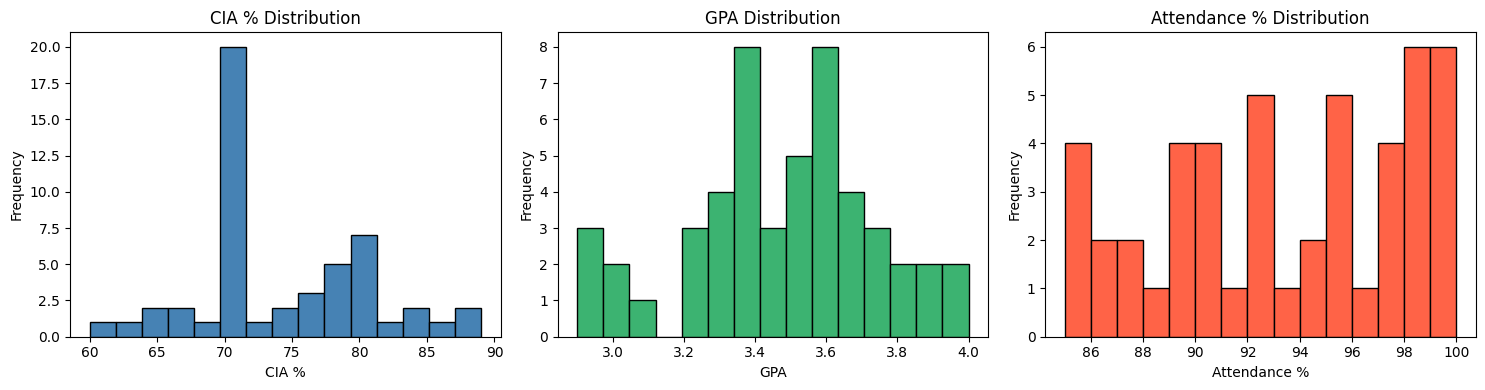

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['cia_pct'].plot(kind='hist', ax=axes[0], bins=15, color='steelblue', edgecolor='black')
axes[0].set_title('CIA % Distribution')
axes[0].set_xlabel('CIA %')

df['gpa'].plot(kind='hist', ax=axes[1], bins=15, color='mediumseagreen', edgecolor='black')
axes[1].set_title('GPA Distribution')
axes[1].set_xlabel('GPA')

df['attendance_pct'].plot(kind='hist', ax=axes[2], bins=15, color='tomato', edgecolor='black')
axes[2].set_title('Attendance % Distribution')
axes[2].set_xlabel('Attendance %')

plt.tight_layout()
plt.show()

In [22]:
print("Percentage: \n")
print(f"Mean:   {df['cia_pct'].mean():.2f}")
print(f"Median: {df['cia_pct'].median():.2f}")

print("\nGPA\n")
print(f"Mean:   {df['gpa'].mean():.2f}")
print(f"Median: {df['gpa'].median():.2f}")

print("\nAttendance %: \n")
print(f"Mean:   {df['attendance_pct'].mean():.2f}")
print(f"Median: {df['attendance_pct'].median():.2f}")

Percentage: 

Mean:   74.05
Median: 71.11

GPA

Mean:   3.48
Median: 3.50

Attendance %: 

Mean:   93.12
Median: 93.50


**CIA %** — Mean: 74.05 | Median: 71.11
Gap of ~3 points suggests mild right skew, a few high scorers pulling the mean up. Median is safer here.

**GPA** — Mean: 3.48 | Median: 3.50
Mean and median are almost identical, distribution is symmetric. Either works, using mean.

**Attendance %** — Mean: 93.12 | Median: 93.50
Very close values, slight left skew from a few low attenders pulling mean down. Median is safer here.

In [23]:
df['cia_pct'].fillna(df['cia_pct'].median(), inplace=True)
df['gpa'].fillna(df['gpa'].mean(), inplace=True)
df['attendance_pct'].fillna(df['attendance_pct'].median(), inplace=True)

print(df[['cia_pct', 'gpa', 'attendance_pct']].isna().sum())

cia_pct           0
gpa               0
attendance_pct    0
dtype: int64


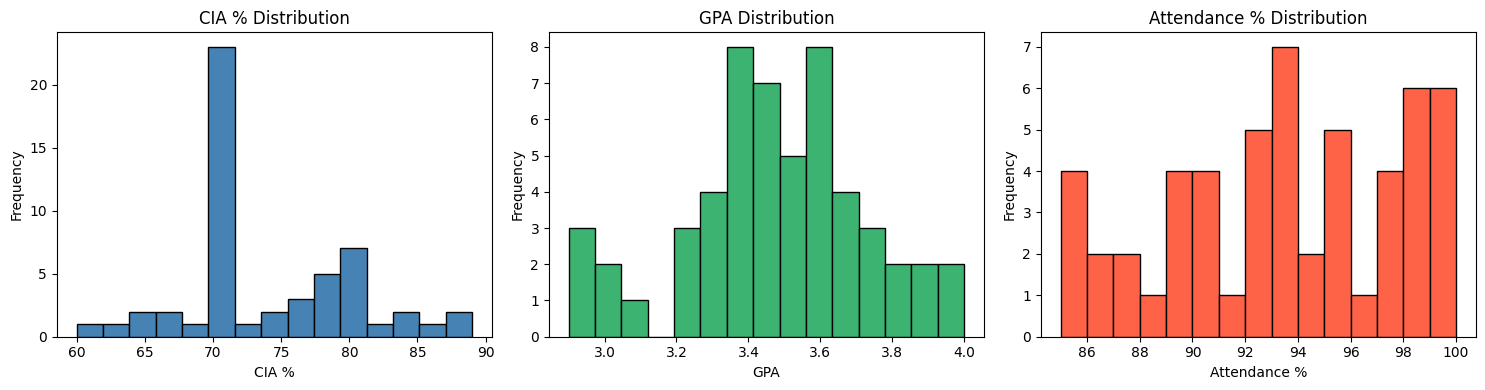

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['cia_pct'].plot(kind='hist', ax=axes[0], bins=15, color='steelblue', edgecolor='black')
axes[0].set_title('CIA % Distribution')
axes[0].set_xlabel('CIA %')

df['gpa'].plot(kind='hist', ax=axes[1], bins=15, color='mediumseagreen', edgecolor='black')
axes[1].set_title('GPA Distribution')
axes[1].set_xlabel('GPA')

df['attendance_pct'].plot(kind='hist', ax=axes[2], bins=15, color='tomato', edgecolor='black')
axes[2].set_title('Attendance % Distribution')
axes[2].set_xlabel('Attendance %')

plt.tight_layout()
plt.show()

In [25]:
print("Percentage: \n")
print(f"Mean:   {df['cia_pct'].mean():.2f}")
print(f"Median: {df['cia_pct'].median():.2f}")

print("\nGPA\n")
print(f"Mean:   {df['gpa'].mean():.2f}")
print(f"Median: {df['gpa'].median():.2f}")

print("\nAttendance %: \n")
print(f"Mean:   {df['attendance_pct'].mean():.2f}")
print(f"Median: {df['attendance_pct'].median():.2f}")

Percentage: 

Mean:   73.89
Median: 71.11

GPA

Mean:   3.48
Median: 3.48

Attendance %: 

Mean:   93.16
Median: 93.50


Distribution after imputation remains the same

In [26]:
remaining = ['min_salary_lpa', 'max_salary_lpa', 'median_salary_lpa', 
             'package_expectation_lpa', 'top_company', 'job_role', 
             'internship_interest']

for col in remaining:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())


=== min_salary_lpa ===
min_salary_lpa
5              8
4.5            6
4              6
6              4
3              3
4,00,000       2
3.3            2
300000         2
7              2
4 LPA          2
7,00,000       1
3,00,000       1
3.5            1
5,00,000.00    1
3.4            1
8              1
6lpa           1
2.7            1
12LPA          1
4 lpa          1
1500000        1
2              1
12             1
4.5 LPA        1
10lpa          1
6 LPA          1
20000          1
Name: count, dtype: int64

=== max_salary_lpa ===
max_salary_lpa
12              23
Option 1         9
24               3
12 LPA           3
25               2
17               1
8                1
22,00,000        1
12lpa            1
12,00,000.00     1
10,00,000        1
22 lpa           1
1200000          1
1300000          1
15               1
14               1
20               1
100lpa           1
80000            1
Name: count, dtype: int64

=== median_salary_lpa ===
median_salary_lpa
7    

In [27]:
import re

def clean_salary(val):
    val = str(val).strip().lower()
    
    # unusable
    if val.startswith('option'):
        return np.nan
    if val == 'nan':
        return np.nan
    
    # crore handling
    if 'cr' in val:
        val = val.replace('cr', '').replace('crore', '').strip()
        return float(val) * 100
    
    # strip "lpa" text
    val = val.replace('lpa', '').strip()
    
    # range handling like "3-4" or "3 - 4"
    if '-' in val:
        parts = val.split('-')
        try:
            return (float(parts[0].strip()) + float(parts[1].strip())) / 2
        except:
            return np.nan
    
    # strip commas (for 7,00,000 style)
    val = val.replace(',', '').strip()
    
    # convert to float
    try:
        val = float(val)
    except:
        return np.nan
    
    if val >= 10000:
        return val / 100000
    
    return val

df['min_salary_lpa'] = df['min_salary_lpa'].apply(clean_salary)
df['max_salary_lpa'] = df['max_salary_lpa'].apply(clean_salary)
df['median_salary_lpa'] = df['median_salary_lpa'].apply(clean_salary)
df['package_expectation_lpa'] = df['package_expectation_lpa'].apply(clean_salary)

for col in ['min_salary_lpa', 'max_salary_lpa', 'median_salary_lpa', 'package_expectation_lpa']:
    print(f"{col}:\n {df[col].isna().sum()} NaNs")
    print(df[col].describe())
    print()

min_salary_lpa:
 0 NaNs
count    54.000000
mean      5.016667
std       2.512816
min       0.200000
25%       4.000000
50%       4.500000
75%       5.750000
max      15.000000
Name: min_salary_lpa, dtype: float64

max_salary_lpa:
 9 NaNs
count     45.000000
mean      15.817778
std       13.739910
min        0.800000
25%       12.000000
50%       12.000000
75%       14.000000
max      100.000000
Name: max_salary_lpa, dtype: float64

median_salary_lpa:
 0 NaNs
count    54.000000
mean      8.098148
std       5.725464
min       4.500000
25%       6.000000
50%       7.000000
75%       8.000000
max      45.000000
Name: median_salary_lpa, dtype: float64

package_expectation_lpa:
 3 NaNs
count     51.000000
mean      13.931373
std       27.641277
min        5.000000
25%        7.000000
50%        8.500000
75%       12.000000
max      200.000000
Name: package_expectation_lpa, dtype: float64



In [28]:
for col in remaining:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())


=== min_salary_lpa ===
min_salary_lpa
4.0     11
5.0      9
4.5      7
6.0      6
3.0      6
7.0      3
12.0     2
3.3      2
8.0      1
3.4      1
3.5      1
2.7      1
15.0     1
2.0      1
10.0     1
0.2      1
Name: count, dtype: int64

=== max_salary_lpa ===
max_salary_lpa
12.0     29
24.0      3
22.0      2
25.0      2
17.0      1
10.0      1
8.0       1
13.0      1
15.0      1
14.0      1
20.0      1
100.0     1
0.8       1
Name: count, dtype: int64

=== median_salary_lpa ===
median_salary_lpa
7.0     16
6.0     10
8.0      4
5.0      4
4.5      3
6.9      3
9.0      2
10.0     2
6.3      2
8.5      1
12.0     1
15.0     1
7.5      1
11.0     1
9.5      1
20.0     1
45.0     1
Name: count, dtype: int64

=== package_expectation_lpa ===
package_expectation_lpa
10.0     10
8.0      10
7.0       7
6.0       6
12.0      5
15.0      3
13.0      3
5.0       2
9.0       1
8.5       1
200.0     1
14.0      1
60.0      1
Name: count, dtype: int64

=== top_company ===
top_company
DE Shaw 

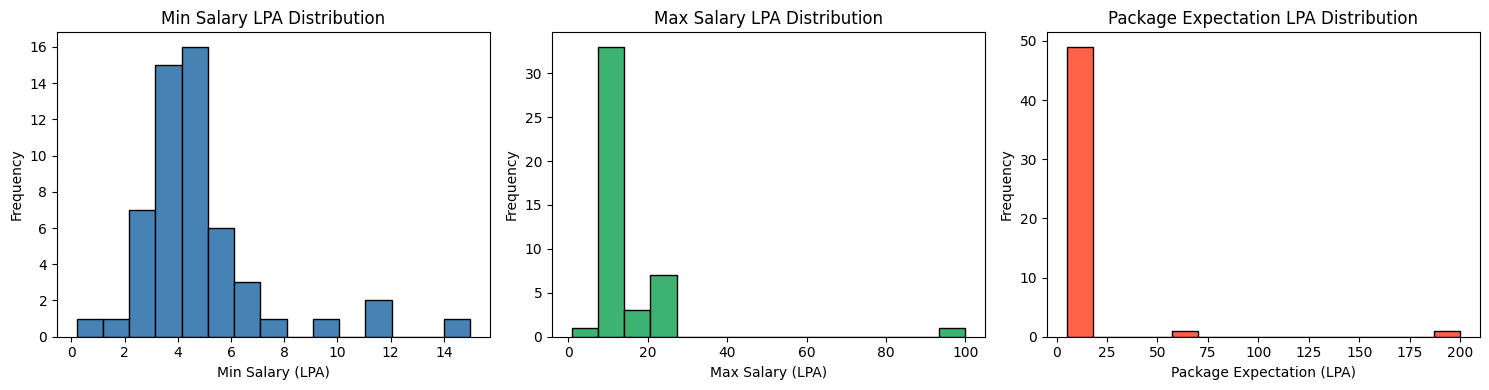


=== min_salary_lpa ===
Mean:   5.02
Median: 4.50

=== max_salary_lpa ===
Mean:   15.82
Median: 12.00

=== package_expectation_lpa ===
Mean:   13.93
Median: 8.50


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['min_salary_lpa'].plot(kind='hist', ax=axes[0], bins=15, color='steelblue', edgecolor='black')
axes[0].set_title('Min Salary LPA Distribution')
axes[0].set_xlabel('Min Salary (LPA)')

df['max_salary_lpa'].plot(kind='hist', ax=axes[1], bins=15, color='mediumseagreen', edgecolor='black')
axes[1].set_title('Max Salary LPA Distribution')
axes[1].set_xlabel('Max Salary (LPA)')

df['package_expectation_lpa'].plot(kind='hist', ax=axes[2], bins=15, color='tomato', edgecolor='black')
axes[2].set_title('Package Expectation LPA Distribution')
axes[2].set_xlabel('Package Expectation (LPA)')

plt.tight_layout()
plt.show()

for col in ['min_salary_lpa', 'max_salary_lpa', 'package_expectation_lpa']:
    print(f"\n=== {col} ===")
    print(f"Mean:   {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")

No imputation for Median

In [30]:
df['max_salary_lpa'].fillna(df['max_salary_lpa'].median(), inplace=True)
df['package_expectation_lpa'].fillna(df['package_expectation_lpa'].median(), inplace=True)

print(df.isna().sum())

timestamp                  0
reg_no                     0
email                      0
job_role                   0
min_salary_lpa             0
max_salary_lpa             0
median_salary_lpa          0
top_company                0
extracurricular_rating     0
tech_rating                0
package_expectation_lpa    0
cia_pct                    0
gpa                        0
attendance_pct             0
internship_interest        0
dtype: int64


**7. Remove duplicate records if present**

In [31]:
print(f"Duplicates found: {df.duplicated().sum()}")

Duplicates found: 0


**8. Generate statistical summary**

In [32]:
df.describe()

,timestamp,min_salary_lpa,max_salary_lpa,median_salary_lpa,extracurricular_rating,tech_rating,package_expectation_lpa,cia_pct,gpa,attendance_pct
count,54,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000,54.00000,54.000000,54.000000
mean,2026-06-22 08:53:31.366500096,5.016667,15.181481,8.098148,3.592593,3.407407,13.629630,73.88963,3.476800,93.163519
min,2026-06-22 08:49:31.362000,0.200000,0.800000,4.500000,2.000000,1.000000,5.000000,60.00000,2.900000,85.000000
25%,2026-06-22 08:52:20.128749824,4.000000,12.000000,6.000000,3.000000,3.000000,7.000000,70.00000,3.377500,90.000000
50%,2026-06-22 08:53:30.697499904,4.500000,12.000000,7.000000,4.000000,3.000000,8.500000,71.11000,3.478400,93.500000
75%,2026-06-22 08:54:18.161750016,5.750000,12.000000,8.000000,4.000000,4.000000,11.500000,78.99750,3.600000,97.000000
max,2026-06-22 08:57:57.108000,15.000000,100.000000,45.000000,5.000000,5.000000,200.000000,89.00000,4.000000,100.000000
std,NaN,2.512816,12.601184,5.725464,0.981307,0.835950,26.876936,6.42520,0.258752,4.528431


**9. Select appropriate dependent and independent variables**

For this analysis, **GPA** is selected as the dependent variable since it represents the academic outcome to be predicted. **CIA percentage** and **Attendance percentage** are treated as independent variables because they are expected to influence a student's academic performance and may serve as predictors of GPA in the regression models.


## Part B: Simple Linear Regression using Scikit-learn

### Regression Experiments: Experiment 1

Independent Variable (X): CIA Percentage

Dependent Variable (Y): GPA

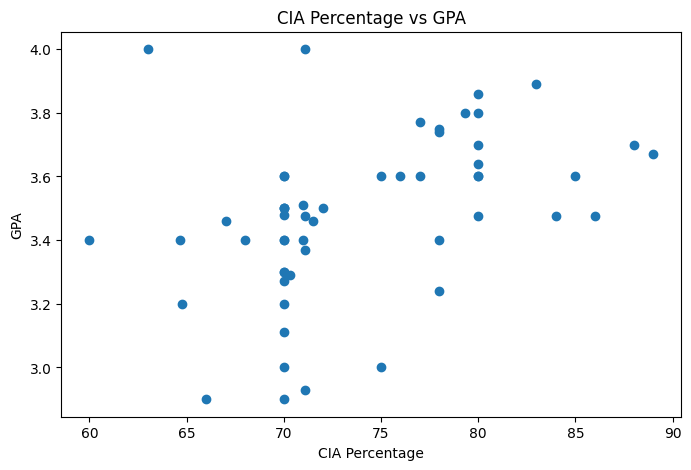

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['cia_pct'], df['gpa'])
plt.xlabel('CIA Percentage')
plt.ylabel('GPA')
plt.title('CIA Percentage vs GPA')
plt.show()

In [34]:
correlation = df['cia_pct'].corr(df['gpa'])

print(f"Correlation Coefficient: {correlation:.4f}")

Correlation Coefficient: 0.4111


Moderate Correlation between CIA% and GPA

In [35]:
X = df[['cia_pct']]
y = df['gpa']

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42)

In [37]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [38]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


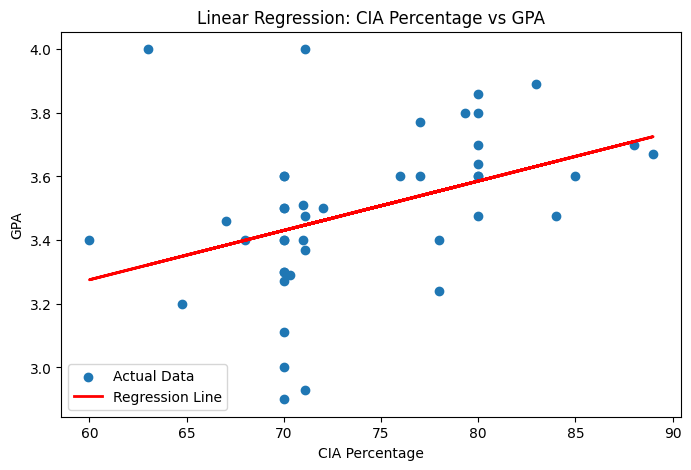

In [39]:
plt.figure(figsize=(8,5))

plt.scatter(X_train, y_train, label='Actual Data')

plt.plot(
    X_train,
    model.predict(X_train),
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.xlabel('CIA Percentage')
plt.ylabel('GPA')
plt.title('Linear Regression: CIA Percentage vs GPA')
plt.legend()
plt.show()

In [40]:
slope = model.coef_[0]
slope

np.float64(0.01550953180679792)

In [41]:
intercept = model.intercept_
intercept

np.float64(2.344861579132017)

**GPA=2.3449+0.0155×(CIA Percentage)**

In [42]:
y_pred = model.predict(X_test)

In [43]:
results = pd.DataFrame({'Actual GPA': y_test,'Predicted GPA': y_pred})
results

,Actual GPA,Predicted GPA
19,3.7500,3.554605
49,3.7400,3.554605
48,3.4600,3.453793
12,3.4800,3.430529
44,3.0000,3.508076
5,3.5000,3.430529
17,2.9000,3.368491
52,3.4768,3.678681
3,3.2000,3.430529
32,3.6000,3.508076


In [44]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = mse ** 0.5


print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")
print("RMSE:", rmse)


MSE: 0.0602
R² Score: 0.1201
RMSE: 0.2454227606372608


The Simple Linear Regression model produced an MSE of 0.0602 and an R² score of 0.1201. This indicates that CIA percentage explains approximately 12.01% of the variation in GPA. While a relationship exists between CIA percentage and GPA, the low R² value suggests that CIA percentage alone is not a strong predictor of GPA, and additional factors may influence student academic performance.

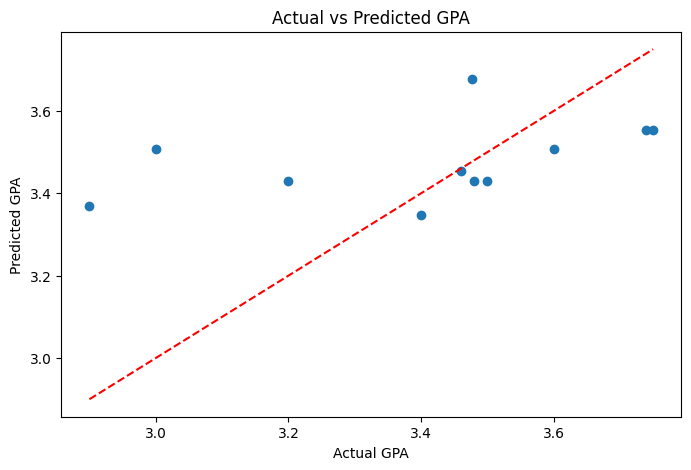

In [45]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Actual vs Predicted GPA")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

### Regression Experiments: Experiment 2

Independent Variable (X):Attendance Percentage

Dependent Variable (Y):GPA

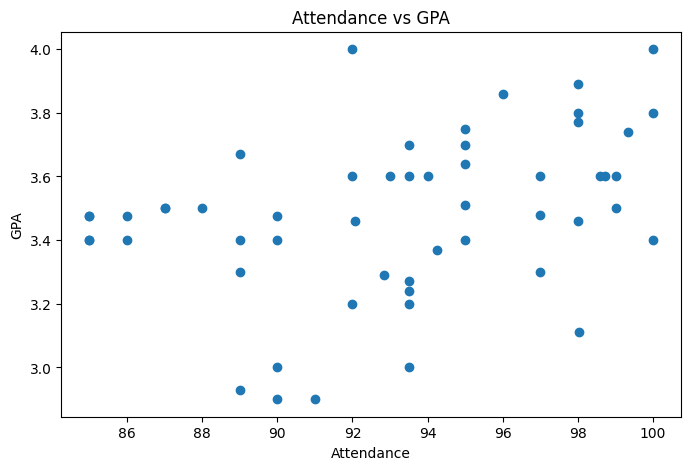

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['attendance_pct'], df['gpa'])
plt.xlabel('Attendance')
plt.ylabel('GPA')
plt.title('Attendance vs GPA')
plt.show()

In [47]:
correlation = df['attendance_pct'].corr(df['gpa'])

print(f"Correlation Coefficient: {correlation:.4f}")

Correlation Coefficient: 0.3593


Moderate Correlation

In [48]:
X = df[['attendance_pct']]
y = df['gpa']

In [49]:
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42)

In [50]:
model = LinearRegression()

In [51]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


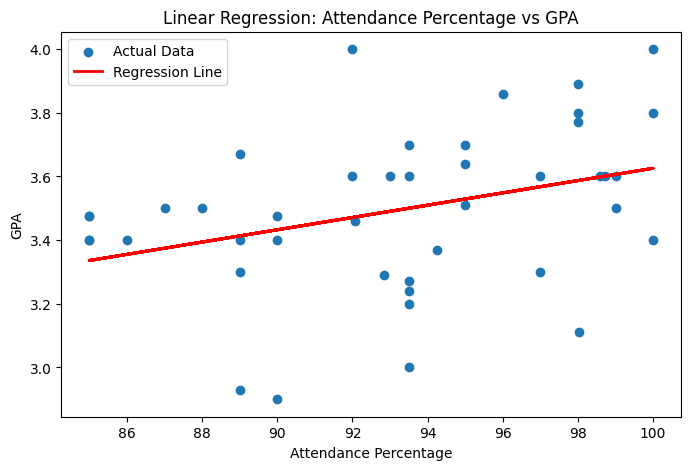

In [52]:
plt.figure(figsize=(8,5))

plt.scatter(X_train, y_train, label='Actual Data')

plt.plot(
    X_train,
    model.predict(X_train),
    color='red',
    linewidth=2,
    label='Regression Line'
)

plt.xlabel('Attendance Percentage')
plt.ylabel('GPA')
plt.title('Linear Regression: Attendance Percentage vs GPA')
plt.legend()
plt.show()

In [53]:
slope= model.coef_[0]
slope

np.float64(0.019322402070930896)

In [54]:
intercept = model.intercept_
intercept

np.float64(1.6936137052752585)

**GPA = 0.019(Attendance %)+1.69**

In [55]:
y_pred = model.predict(X_test)

In [56]:
results = pd.DataFrame({'Actual GPA': y_test,'Predicted GPA': y_pred})
results

,Actual GPA,Predicted GPA
19,3.7500,3.529242
49,3.7400,3.613101
48,3.4600,3.587209
12,3.4800,3.567887
44,3.0000,3.432630
5,3.5000,3.374663
17,2.9000,3.451952
52,3.4768,3.355340
3,3.2000,3.471275
32,3.6000,3.509919


In [57]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")

MSE: 0.0645
R² Score: 0.0578


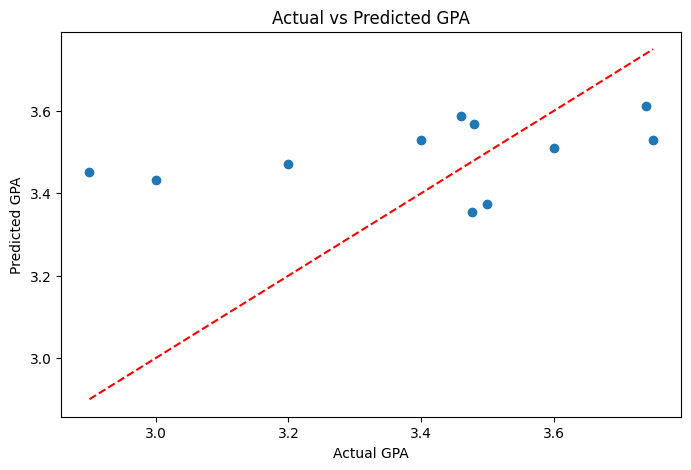

In [58]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Actual vs Predicted GPA")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

## Part C: Manual Computation using Ordinary Least Squares (OLS)

In [59]:
X = df[['attendance_pct']]
y = df['gpa']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Arrays initialized for manual OLS computation.

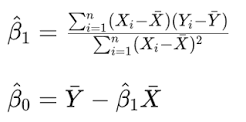

In [60]:
X_train_arr = X_train['attendance_pct'].to_numpy()
y_train_arr = y_train.to_numpy()

In [61]:
X_mean = np.mean(X_train_arr)
y_mean = np.mean(y_train_arr)

numerator = np.sum((X_train_arr - X_mean) * (y_train_arr - y_mean))
denominator = np.sum((X_train_arr - X_mean) ** 2)

manual_slope = numerator / denominator
manual_intercept = y_mean - (manual_slope * X_mean)

print("Manual OLS Parameters")
print(f"Manual Slope: {manual_slope}")
print(f"Manual Intercept: {manual_intercept}")
print(f" Equation: GPA = {manual_intercept:.4f} + {manual_slope:.4f} * (attendance_pct)")

Manual OLS Parameters
Manual Slope: 0.0193224020709309
Manual Intercept: 1.693613705275258
 Equation: GPA = 1.6936 + 0.0193 * (attendance_pct)


In [62]:
X_test_arr = X_test['attendance_pct'].to_numpy()
manual_predictions = manual_intercept + (manual_slope * X_test_arr)

In [63]:
difference = y_pred - manual_predictions

comparison_df = pd.DataFrame({
    'Actual GPA': y_test,
    'Scikit-learn Prediction': y_pred,
    'Manual OLS Prediction': manual_predictions,
    'Difference': difference
})

print("Prediction Comparison:")
print(comparison_df.head(10))  # Shows the first 10 rows

Prediction Comparison:
    Actual GPA  Scikit-learn Prediction  Manual OLS Prediction    Difference
19      3.7500                 3.529242               3.529242  4.440892e-16
49      3.7400                 3.613101               3.613101  0.000000e+00
48      3.4600                 3.587209               3.587209  0.000000e+00
12      3.4800                 3.567887               3.567887  0.000000e+00
44      3.0000                 3.432630               3.432630  0.000000e+00
5       3.5000                 3.374663               3.374663  0.000000e+00
17      2.9000                 3.451952               3.451952  4.440892e-16
52      3.4768                 3.355340               3.355340  0.000000e+00
3       3.2000                 3.471275               3.471275  0.000000e+00
32      3.6000                 3.509919               3.509919  0.000000e+00


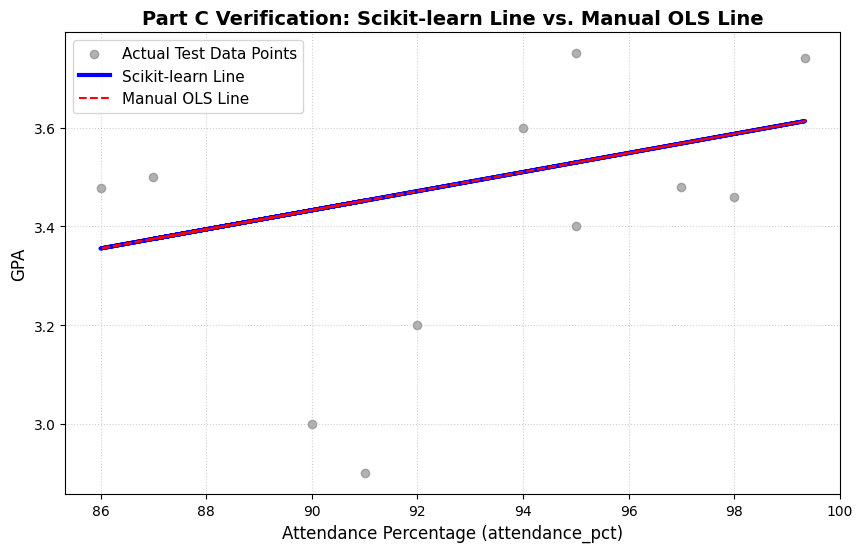

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X_test_arr, y_test, color='gray', alpha=0.6, label='Actual Test Data Points')

plt.plot(X_test_arr, y_pred, color='blue', linewidth=3, linestyle='-', label='Scikit-learn Line')

plt.plot(X_test_arr, manual_predictions, color='red', linewidth=1.5, linestyle='--', label='Manual OLS Line')

plt.title('Part C Verification: Scikit-learn Line vs. Manual OLS Line', fontsize=14, fontweight='bold')
plt.xlabel('Attendance Percentage (attendance_pct)', fontsize=12)
plt.ylabel('GPA', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)

plt.show()

# **Lab 3: PART 2**

In [65]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shyamnadhs/heart-disease-prediction-dataset")

print("Path to dataset files:", path)

C:\Users\neha_\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\neha_\.cache\kagglehub\datasets\shyamnadhs\heart-disease-prediction-dataset\versions\3


In [66]:
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
df= pd.read_csv("C:/Users/neha_/.cache/kagglehub/datasets/shyamnadhs/heart-disease-prediction-dataset/versions/3/disease_prediction.csv")
df.head()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


In [67]:
df.shape

(1000, 14)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   object 
 3   glucose_mg_dl        1000 non-null   int64  
 4   cholesterol_mg_dl    1000 non-null   int64  
 5   systolic_bp          1000 non-null   int64  
 6   diastolic_bp         1000 non-null   int64  
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   int64  
 9   smoking              1000 non-null   object 
 10  alcohol_consumption  1000 non-null   object 
 11  physical_activity    1000 non-null   object 
 12  family_history       1000 non-null   object 
 13  disease              1000 non-null   object 
dtypes: float64(1), int64(7), object(6)
memory usage: 109.5+ KB


In [69]:
df.describe()

,patient_id,age,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,51.190000,104.163000,210.014000,123.893000,81.032000,26.093000,75.968000
std,288.819436,19.847514,25.076508,39.749111,18.701211,9.969974,4.758282,9.902982
min,1.000000,18.000000,30.000000,89.000000,67.000000,49.000000,16.000000,47.000000
25%,250.750000,33.000000,87.000000,183.000000,111.000000,74.000000,22.900000,70.000000
50%,500.500000,52.500000,105.000000,210.500000,124.000000,81.000000,26.000000,76.000000
75%,750.250000,69.000000,121.000000,235.250000,135.000000,88.000000,29.300000,83.000000
max,1000.000000,85.000000,184.000000,339.000000,195.000000,113.000000,41.500000,114.000000


Checking for missing data

In [70]:
print(df.isnull().sum())
print()
print("Total missing values:", df.isnull().sum().sum())

patient_id             0
age                    0
gender                 0
glucose_mg_dl          0
cholesterol_mg_dl      0
systolic_bp            0
diastolic_bp           0
bmi                    0
heart_rate             0
smoking                0
alcohol_consumption    0
physical_activity      0
family_history         0
disease                0
dtype: int64

Total missing values: 0


Handling Categorical Fields

In [71]:
df = df.drop(columns=['patient_id'])

df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

bool_cols = ['smoking', 'alcohol_consumption', 'family_history', 'disease']
for col in bool_cols:
    if df[col].dtype == object:
        df[col] = df[col].astype(str).str.strip().str.lower().map({
            'yes': 1, 'no': 0,
            'true': 1, 'false': 0   # kept as a fallback in case some rows use this format instead
        })
    else:
        df[col] = df[col].astype(int)
    print(col, "- NaNs after encoding:", df[col].isnull().sum())

smoking - NaNs after encoding: 0
alcohol_consumption - NaNs after encoding: 0
family_history - NaNs after encoding: 0
disease - NaNs after encoding: 0


In [72]:
df.head()

,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,32,0,101,235,152,79,28.5,73,0,1,Low,1,1
1,31,0,124,191,134,77,33.9,71,0,1,Low,1,1
2,45,0,57,141,114,71,27.2,79,1,1,Low,0,0
3,75,1,69,268,120,82,21.5,61,1,1,Medium,0,1
4,53,0,107,163,131,75,23.3,73,1,0,Low,1,1


In [73]:
print(df['gender'].unique())
print(df['smoking'].unique())
print(df['alcohol_consumption'].unique())
print(df['family_history'].unique())
print(df['disease'].unique())

[0 1]
[0 1]
[1 0]
[1 0]
[1 0]


In [74]:

print(df['physical_activity'].unique())
print(df['physical_activity'].dtype)

['Low' 'Medium' 'High']
object


In [75]:
activity_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['physical_activity'] = df['physical_activity'].map(activity_map)

print(df['physical_activity'].unique())   # should show [0 1 2] or similar, no NaN
print(df['physical_activity'].isnull().sum())

[0 1 2]
0


In [76]:
print(df['physical_activity'].unique())
print(df['physical_activity'].dtype)

[0 1 2]
int64


In [77]:
target = 'disease'
X = df.drop(columns=[target])
y = df[target]

numeric_features = ['age', 'glucose_mg_dl', 'cholesterol_mg_dl', 'systolic_bp',
                     'diastolic_bp', 'bmi', 'heart_rate']

X.head()

,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history
0,32,0,101,235,152,79,28.5,73,0,1,0,1
1,31,0,124,191,134,77,33.9,71,0,1,0,1
2,45,0,57,141,114,71,27.2,79,1,1,0,0
3,75,1,69,268,120,82,21.5,61,1,1,1,0
4,53,0,107,163,131,75,23.3,73,1,0,0,1


In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (800, 12)
Test shape: (200, 12)


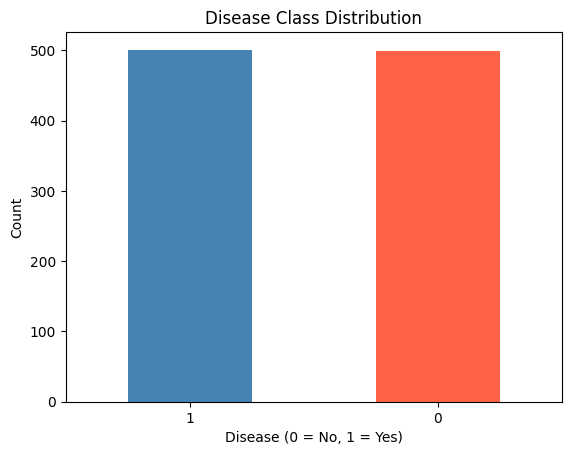

In [79]:
import matplotlib.pyplot as plt

df['disease'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Disease Class Distribution')
plt.xlabel('Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

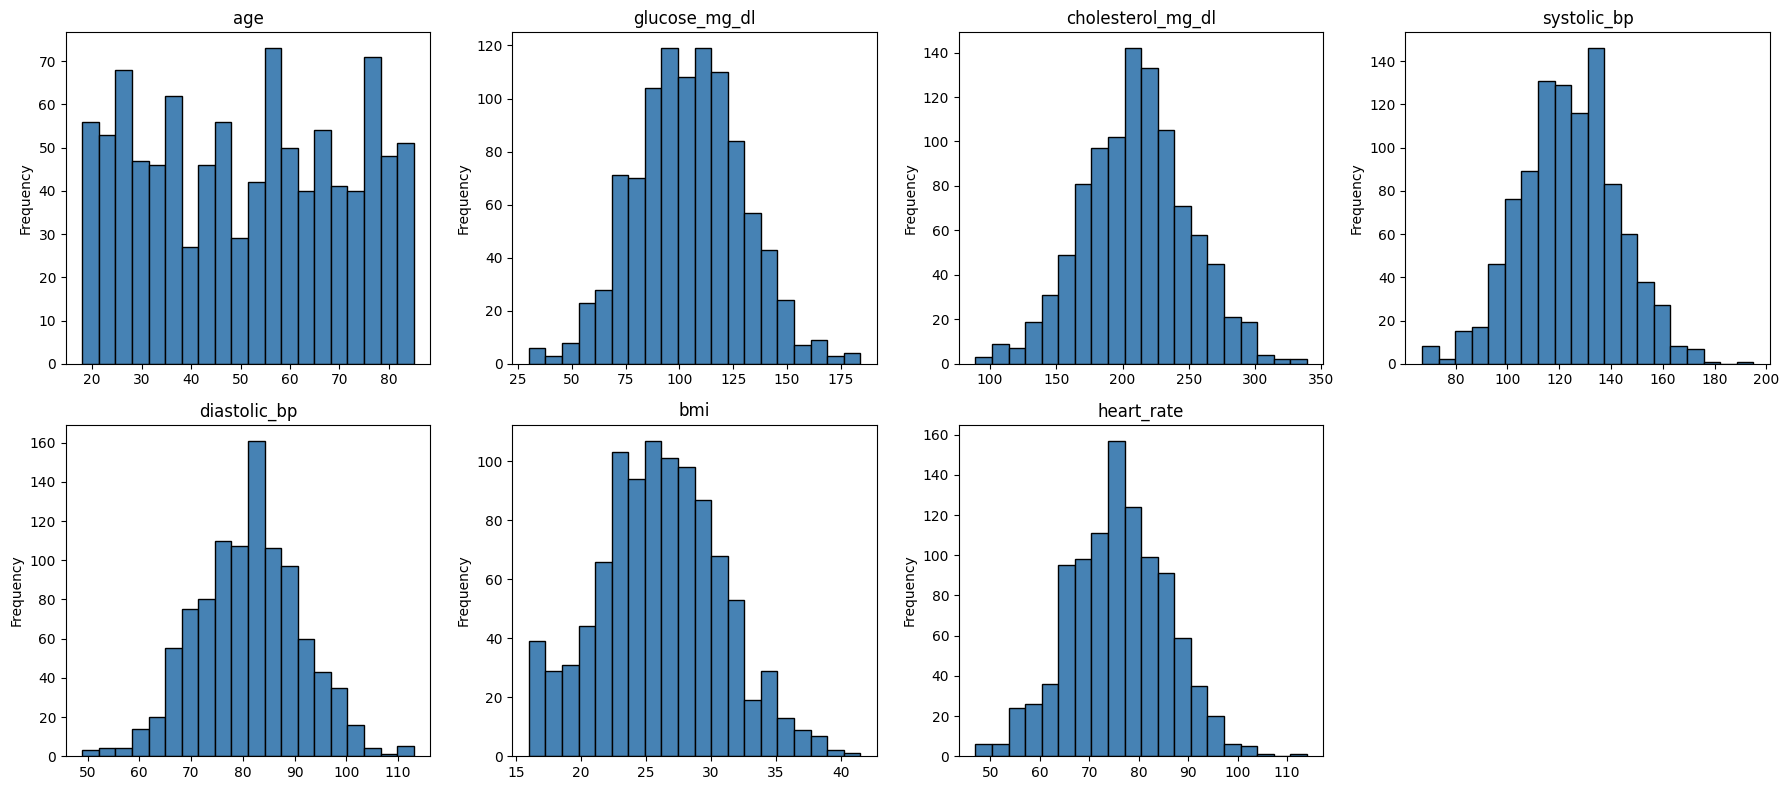

In [85]:
numeric_features = ['age', 'glucose_mg_dl', 'cholesterol_mg_dl', 'systolic_bp',
                     'diastolic_bp', 'bmi', 'heart_rate']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    df[col].plot(kind='hist', ax=axes[i], bins=20, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
axes[-1].axis('off')  # hide the unused 8th subplot
plt.tight_layout()
plt.show()

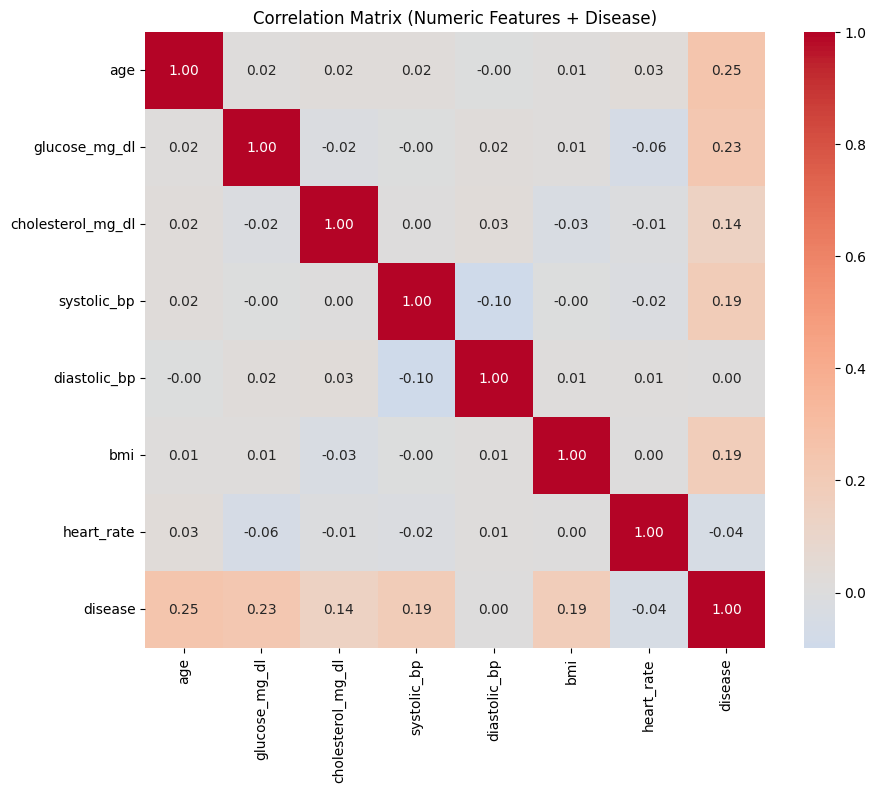

In [86]:
import seaborn as sns

plt.figure(figsize=(10, 8))
corr = df[numeric_features + ['disease']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Numeric Features + Disease)')
plt.show()

In [80]:
model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Sample predictions (test set):", np.round(y_test_pred[:10], 3))
print("Actual values (test set):     ", y_test.values[:10])

Sample predictions (test set): [0.373 0.351 0.175 0.781 0.266 0.636 0.715 0.691 0.839 0.854]
Actual values (test set):      [1 1 0 1 0 1 1 1 1 1]


In [81]:
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}")
    print()
    return mae, mse, rmse, r2

train_metrics = evaluate(y_train, y_train_pred, "Training set")
test_metrics  = evaluate(y_test, y_test_pred, "Test set")

--- Training set ---
MAE:  0.2965
MSE:  0.1244
RMSE: 0.3527
R2:   0.5024

--- Test set ---
MAE:  0.2964
MSE:  0.1233
RMSE: 0.3512
R2:   0.5054



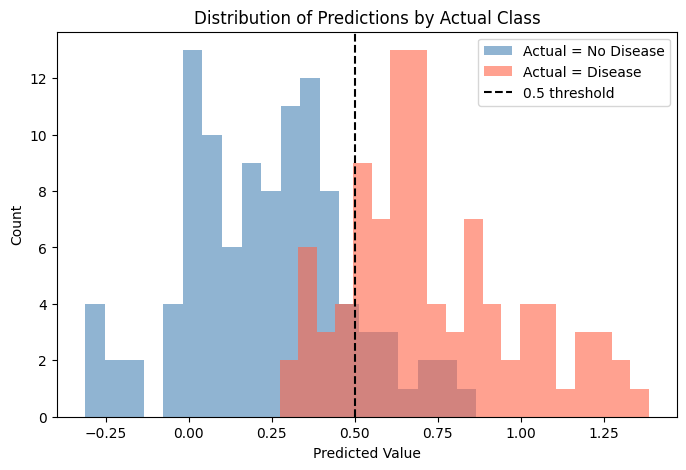

In [88]:
plt.figure(figsize=(8, 5))
plt.hist(y_test_pred[y_test == 0], bins=20, alpha=0.6, label='Actual = No Disease', color='steelblue')
plt.hist(y_test_pred[y_test == 1], bins=20, alpha=0.6, label='Actual = Disease', color='tomato')
plt.axvline(x=0.5, color='black', linestyle='--', label='0.5 threshold')
plt.xlabel('Predicted Value')
plt.ylabel('Count')
plt.title('Distribution of Predictions by Actual Class')
plt.legend()
plt.show()

In [82]:
print("Train R2:", round(train_metrics[3], 4), " | Test R2:", round(test_metrics[3], 4))
print("Train RMSE:", round(train_metrics[2], 4), " | Test RMSE:", round(test_metrics[2], 4))
print("Gap (Train R2 - Test R2):", round(train_metrics[3] - test_metrics[3], 4))

Train R2: 0.5024  | Test R2: 0.5054
Train RMSE: 0.3527  | Test RMSE: 0.3512
Gap (Train R2 - Test R2): -0.003


In [83]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df)

                feature  coefficient
11       family_history     0.288673
8               smoking     0.283793
10    physical_activity    -0.220765
0                   age     0.126118
9   alcohol_consumption     0.121464
2         glucose_mg_dl     0.110499
4           systolic_bp     0.097421
6                   bmi     0.092771
3     cholesterol_mg_dl     0.068927
7            heart_rate    -0.023922
1                gender     0.004582
5          diastolic_bp    -0.001855


In [84]:
cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')

print("R2 scores per fold:", np.round(cv_scores, 4))
print("Mean R2:", round(cv_scores.mean(), 4))
print("Std R2:", round(cv_scores.std(), 4))

R2 scores per fold: [0.5228 0.4209 0.4462 0.5219 0.5195]
Mean R2: 0.4863
Std R2: 0.0438
